# 04 - EXPLORATION VISUELLE DU CORPUS

Apercu statistique et graphique de l'ensemble du corpus annoté : longueur de phrases, distribution des POS, top lemmes par auteur, courbe de Zipf, richesse lexicale.

Tout part du chargement uniformisé via `pipeline.corpus.charger_corpus()`.


## Setup

In [1]:
import sys
from pathlib import Path

# Se déplacer dans le dossier du projet (NE LANCER Q'UNE FOIS)
%cd ../
%ls

/data/projets/EVAL_MASTER1/projet_nlp_app
'BC02 - Projet - 2.pdf'     audit_corpus.png*          notebooks/
 Dockerfile                 audit_corpus.py            pg_catalog.csv*
 README.md*                 build_serving_bundle.py*   pipeline/
 __pycache__/               conftest.py                requirements-dev.txt*
 api.py                     diagnostic_mmr.png*        requirements.txt
 app/                       diagnostic_mmr.py          resultats/
 audit_clean_border.py      docs/                      scripts/
 audit_clean_borders.txt*   figures/                   start.sh
 audit_corpus.csv*          models/                    tests/


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pipeline.corpus import charger_corpus

CFG = {
    "figures_dir": Path("figures"),
}
CFG["figures_dir"].mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"


## Chargement

In [3]:
corpus = charger_corpus()
print(f"\n{len(corpus)} livres :")
for c in corpus[:5]:
    print(f"  {c['auteur']:35s} -- {c['livre']:40s} ({c['genre']})")


Chargement de 291 livres annotes...


    10/291 livres  (  0.6s ecoulees, 15.5/s, ~18s restantes)


    20/291 livres  (  1.6s ecoulees, 12.3/s, ~22s restantes)


    30/291 livres  (  1.6s ecoulees, 18.4/s, ~14s restantes)


    40/291 livres  (  1.9s ecoulees, 21.1/s, ~12s restantes)


...

   280/291 livres  ( 13.4s ecoulees, 24.4/s, ~0s restantes)


   290/291 livres  ( 14.1s ecoulees, 21.1/s, ~0s restantes)


   291/291 livres  ( 14.1s ecoulees, 18.3/s, ~0s restantes)


  1 override(s) de genre appliques.
  291 livres charges en 14.1s (8 telechargements simultanes)



291 livres :
  Amundsen Roald                      -- En Avion Vers Le Pole Nord               (adventure)
  Bourget Paul                        -- Lecuyere                                 (adventure)
  Chadourne Louis                     -- Le Maitre Du Navire                      (adventure)
  Conrad Joseph                       -- Typhon                                   (adventure)
  Corbiere Edouard                    -- Les Trois Pirates 22                     (adventure)


## Tableau récapitulatif par livre

Une ligne par livre : nombre de tokens, nombre de phrases, taille du vocabulaire (lemmes), longueur moyenne de phrase.


In [4]:
def stats_livre(c):
    df = c["df"]
    return {
        "auteur":     c["auteur"],
        "livre":      c["livre"],
        "genre":      c["genre"],
        "n_tokens":   len(df),
        "n_phrases":  df["sent_id"].nunique(),
        "vocab":      df["lemma"].nunique(),
        "tok_phrase": len(df) / df["sent_id"].nunique(),
    }

stats = pd.DataFrame([stats_livre(c) for c in corpus])
stats.sort_values("n_tokens", ascending=False)


,auteur,livre,genre,n_tokens,n_phrases,vocab,tok_phrase
143,Vidocq Eugene Francois,Les Vrais Mysteres De Paris,mystery,431037,15137,13619,28.475722
173,Hugo Victor,Lhomme Qui Rit,novel,249895,15870,15506,15.746377
183,Zola Emile,Germinal,novel,212183,10375,8895,20.451373
149,Cosquin Emmanuel,Contes Populaires De Lorraine Compares Avec Le...,mythology,208931,8681,9773,24.067619
225,Ducray Duminil M Francois Guillaume,Victor Ou Lenfant De La Foret,romance,200496,10052,7607,19.945881
...,...,...,...,...,...,...,...
22,Fusil Louise,Souvenirs Dune Actrice 33,biography,8728,455,1490,19.182418
147,Bourneville,Le Sabbat Des Sorciers,mythology,8517,343,1977,24.830904
58,Du Veuzit Max,Cest La Loi,drama,8418,669,1239,12.582960
205,Anacreon 574 Bce 496 Bce,Odes Danacreon Traduction Litterale Et Rythmique,poetry,8365,504,1899,16.597222


## Distribution des longueurs de phrases

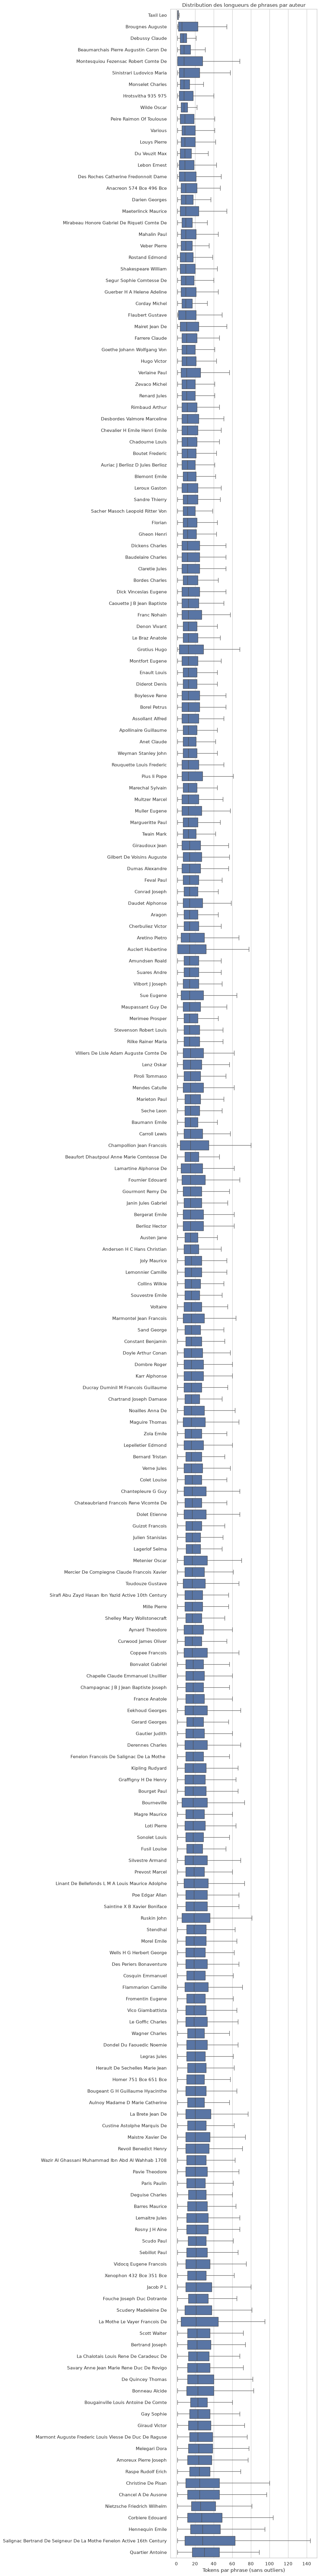

In [5]:
lignes_phrases = []
for c in corpus:
    longueurs = c["df"].groupby("sent_id").size()
    for n in longueurs:
        lignes_phrases.append({"auteur": c["auteur"], "genre": c["genre"], "n_tokens": n})
phrases_df = pd.DataFrame(lignes_phrases)

ordre_auteurs = (
    phrases_df.groupby("auteur")["n_tokens"].median().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(11, max(4, 0.3 * len(corpus))))
sns.boxplot(data=phrases_df, x="n_tokens", y="auteur", order=ordre_auteurs,
            showfliers=False, ax=ax)
ax.set_xlabel("Tokens par phrase (sans outliers)")
ax.set_ylabel("")
ax.set_title("Distribution des longueurs de phrases par auteur")
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "longueurs_phrases.png")
plt.show()


## Distribution des parties du discours

Quels sont les profils d'usage des grandes catégories grammaticales par auteur ?


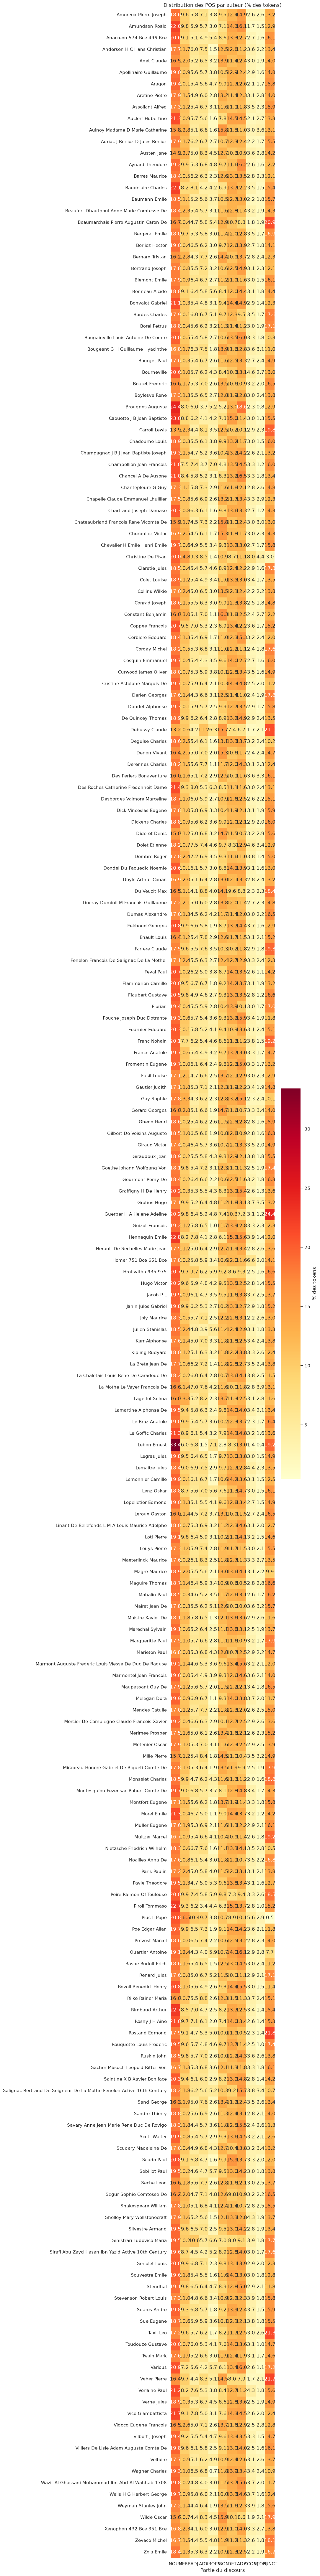

In [6]:
POS_AFFICHES = ["NOUN", "VERB", "ADJ", "ADV", "PROPN", "PRON",
                "DET", "ADP", "CCONJ", "SCONJ", "PUNCT"]

lignes_pos = []
for c in corpus:
    df = c["df"]
    counts = df["pos"].value_counts()
    for pos in POS_AFFICHES:
        lignes_pos.append({
            "auteur": c["auteur"], 
            "pos": pos,
            "nb": int(counts.get(pos, 0)), # On stocke le nombre brut
        })
pos_df = pd.DataFrame(lignes_pos)

# 1. On somme les occurrences par auteur et par POS (au cas où un auteur a plusieurs textes)
pos_df = pos_df.groupby(["auteur", "pos"])["nb"].sum().reset_index()

# 2. On recalcule le pourcentage par auteur sur le total agrégé
total_par_auteur = pos_df.groupby("auteur")["nb"].transform("sum")
pos_df["pct"] = (pos_df["nb"] / total_par_auteur) * 100

# Heatmap
pivot = pos_df.pivot(index="auteur", columns="pos", values="pct")
pivot = pivot[POS_AFFICHES]

fig, ax = plt.subplots(figsize=(11, max(4, 0.3 * len(corpus))))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "% des tokens"})
ax.set_xlabel("Partie du discours")
ax.set_ylabel("")
ax.set_title("Distribution des POS par auteur (% des tokens)")
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "pos_par_auteur.png")
plt.show()


## Top lemmes hors mots-outils

On garde les lemmes alphabetiques, hors stopwords, hors ponctuation, et on prend le top 15 par auteur.


In [7]:
def top_lemmes(df, n=15):
    masque = df["is_alpha"] & ~df["is_stop"] & ~df["is_punct"]
    return df.loc[masque, "lemma"].str.lower().value_counts().head(n)

# Affichage tabulaire
for c in corpus[:5]:
    print(f"\n--- {c['auteur']} -- {c['livre']} ---")
    print(top_lemmes(c['df']).to_string())



--- Amundsen Roald -- En Avion Vers Le Pole Nord ---
lemma
être         240
glace        210
appareil     152
temps        145
banquise     143
heure        127
avion        119
grand        114
départ       106
nord         104
spitzberg    101
jour          92
trouver       92
pouvoir       90
prendre       83

--- Bourget Paul -- Lecuyere ---
lemma
être        370
hilda       366
avoir       316
jeune       307
cheval      285
jules       264
bien        264
maligny     237
faire       203
fille       201
campbell    200
homme       190
corbin      185
trop        171
venir       164

--- Chadourne Louis -- Le Maitre Du Navire ---
lemma
van           276
den           276
brooks        275
helven        235
marie         231
être          213
faire         194
leminhac      181
homme         175
bien          162
erikow        151
avoir         132
fort          123
professeur    109
nuit           99

--- Conrad Joseph -- Typhon ---
lemma
jukes        231
capitaine    176
mac     

## Courbe de Zipf

Loi empirique : la fréquence du n-ième mot le plus fréquent est inversement proportionnelle à son rang. En log-log, on s'attend a une droite.


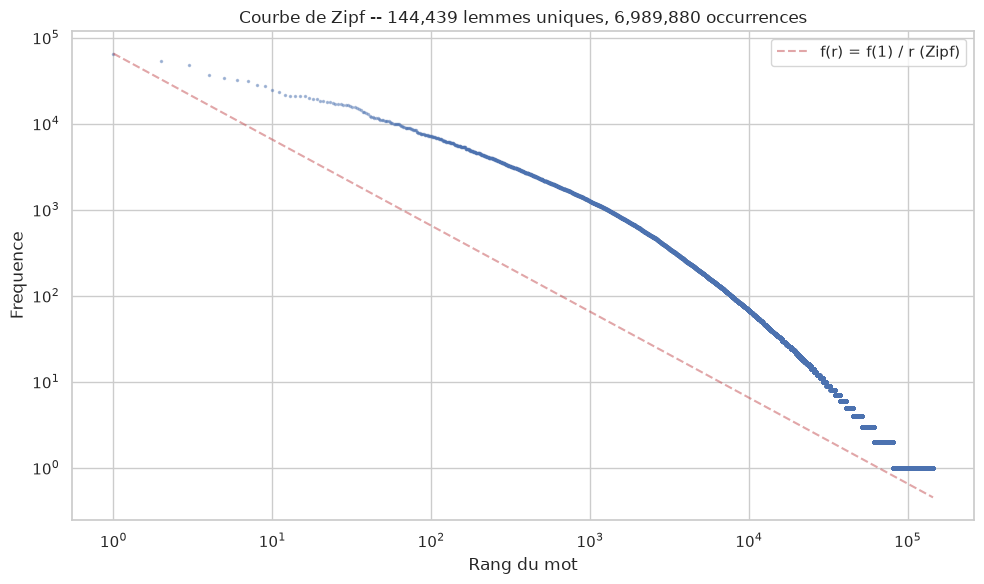

In [8]:
import numpy as np

# Concatener les lemmes filtres de tout le corpus
tous_lemmes = pd.concat([
    c["df"].loc[
        c["df"]["is_alpha"] & ~c["df"]["is_stop"] & ~c["df"]["is_punct"],
        "lemma"
    ].str.lower()
    for c in corpus
])

freq = tous_lemmes.value_counts()
rangs = np.arange(1, len(freq) + 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(rangs, freq.values, ".", alpha=0.4, markersize=3)
# Reference theorique : f(r) = f(1) / r
ref = freq.iloc[0] / rangs
ax.loglog(rangs, ref, "r--", alpha=0.5, label="f(r) = f(1) / r (Zipf)")
ax.set_xlabel("Rang du mot")
ax.set_ylabel("Frequence")
ax.set_title(f"Courbe de Zipf -- {len(freq):,} lemmes uniques, {freq.sum():,} occurrences")
ax.legend()
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "zipf.png")
plt.show()


## Richesse lexicale : vocabulaire vs longueur

Loi de Heaps : la taille du vocabulaire croit comme une racine de la longueur du texte.


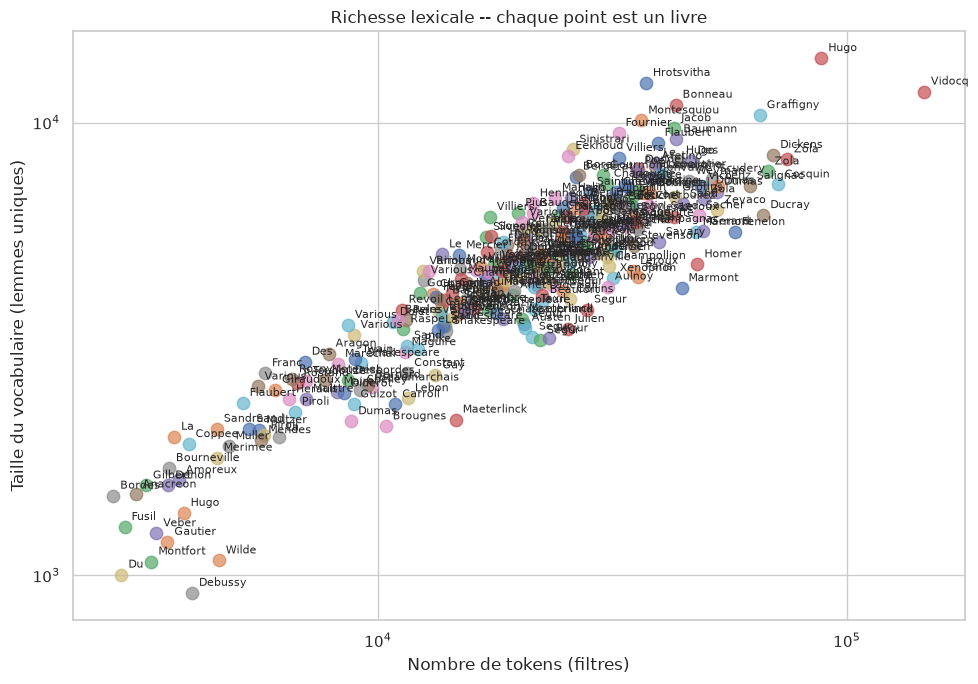

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
for c in corpus:
    n_tok = len(c["lemmes"])
    n_vocab = len(set(c["lemmes"]))
    ax.scatter(n_tok, n_vocab, s=80, alpha=0.7)
    ax.annotate(c["auteur"].split()[0],
                (n_tok, n_vocab),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("Nombre de tokens (filtres)")
ax.set_ylabel("Taille du vocabulaire (lemmes uniques)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Richesse lexicale -- chaque point est un livre")
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "richesse_lexicale.png")
plt.show()
